In [1]:
# ============================
# Imports
# ============================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    roc_curve,
    precision_recall_curve
)
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from xgboost import XGBClassifier

from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.models import Sequential
import tensorflow as tf

In [3]:
# ============================
# Load data & basic info
# ============================

data = pd.read_csv('advertising.csv')

In [5]:
data.head(2)

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0


In [7]:
data.info() # see non-null, dtype, number of columns, number of rows

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  1000 non-null   float64
 1   Age                       1000 non-null   int64  
 2   Area Income               1000 non-null   float64
 3   Daily Internet Usage      1000 non-null   float64
 4   Ad Topic Line             1000 non-null   object 
 5   City                      1000 non-null   object 
 6   Male                      1000 non-null   int64  
 7   Country                   1000 non-null   object 
 8   Timestamp                 1000 non-null   object 
 9   Clicked on Ad             1000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 78.3+ KB


In [9]:
data.describe()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Clicked on Ad
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,65.000200,36.009000,55000.000080,180.000100,0.481000,0.50000
std,15.853615,8.785562,13414.634022,43.902339,0.499889,0.50025
min,32.600000,19.000000,13996.500000,104.780000,0.000000,0.00000
25%,51.360000,29.000000,47031.802500,138.830000,0.000000,0.00000
50%,68.215000,35.000000,57012.300000,183.130000,0.000000,0.50000
75%,78.547500,42.000000,65470.635000,218.792500,1.000000,1.00000
max,91.430000,61.000000,79484.800000,269.960000,1.000000,1.00000


## Exploratory Data Analysis
Using seaborn to explore the data

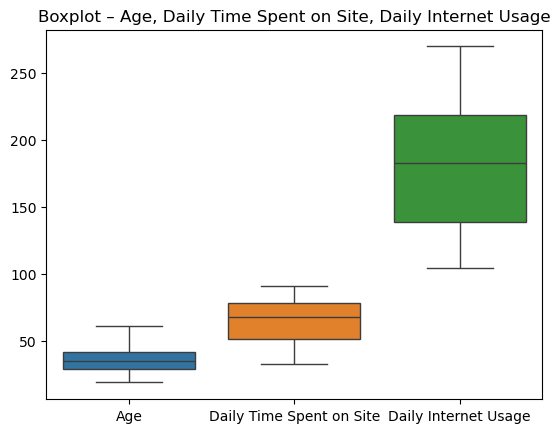

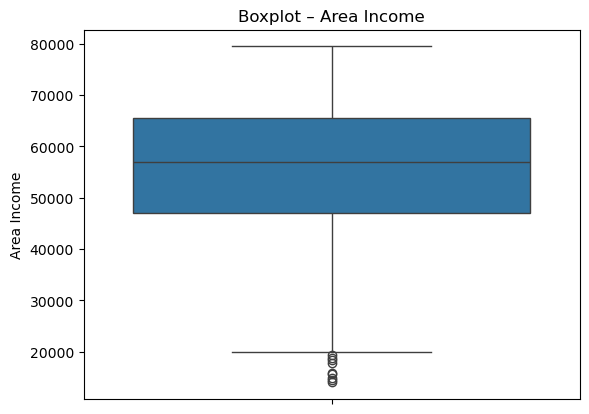

In [12]:
# ============================
# EDA – outliers & distributions
# ============================

# Boxplots
sns.boxplot(data[['Age', 'Daily Time Spent on Site', 'Daily Internet Usage']])
plt.title("Boxplot – Age, Daily Time Spent on Site, Daily Internet Usage")
plt.savefig("fig_outliers.png", dpi=150)
plt.show()

sns.boxplot(data['Area Income'])
plt.title("Boxplot – Area Income")
plt.savefig("fig_distribution.png", dpi=150)
plt.show()

In [14]:
# Target balance
print(data['Clicked on Ad'].value_counts())

Clicked on Ad
0    500
1    500
Name: count, dtype: int64


In [16]:
# Correlation matrix (numeric)
corr = data[['Daily Time Spent on Site',
             'Age',
             'Area Income',
             'Daily Internet Usage',
             'Male',
             'Clicked on Ad']].corr()
corr

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Clicked on Ad
Daily Time Spent on Site,1.000000,-0.331513,0.310954,0.518658,-0.018951,-0.748117
Age,-0.331513,1.000000,-0.182605,-0.367209,-0.021044,0.492531
Area Income,0.310954,-0.182605,1.000000,0.337496,0.001322,-0.476255
Daily Internet Usage,0.518658,-0.367209,0.337496,1.000000,0.028012,-0.786539
Male,-0.018951,-0.021044,0.001322,0.028012,1.000000,-0.038027
Clicked on Ad,-0.748117,0.492531,-0.476255,-0.786539,-0.038027,1.000000


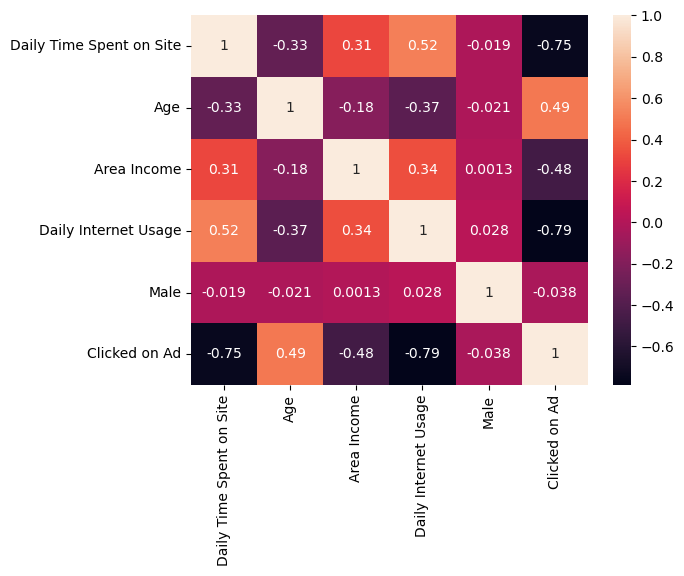

In [18]:
sns.heatmap(data[['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage', 'Male', 'Clicked on Ad']].corr(), annot=True)
plt.savefig("corr_heatmap.png", dpi=150)
plt.show()

Conclusion: most of the features affect on the target (clicked on ad) and there is large coorealation between daily interent usage and daily time spend on site. That can be reduced in 1 column via PCA

<Axes: xlabel='Area Income', ylabel='Count'>

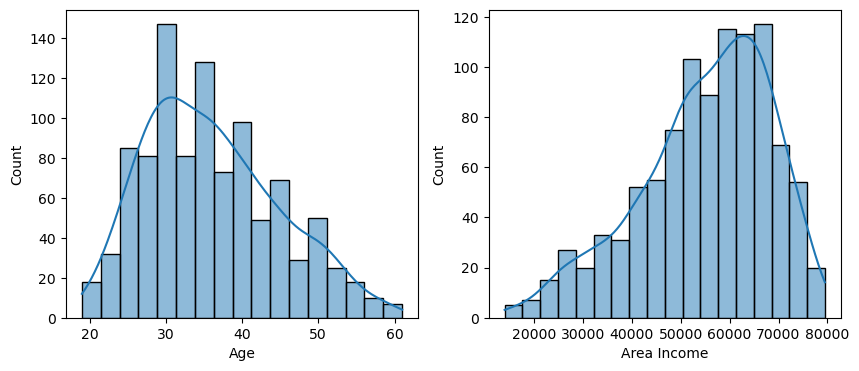

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))
sns.histplot(data['Age'], ax=axes[0], kde=True)
sns.histplot(data['Area Income'], ax=axes[1], kde=True)

Conclusion: See the original distribution for Age and Area Income. They can be done better via QuantileTransformer

** Finally, creating a pairplot with the hue defined by the 'Clicked on Ad' column feature.**

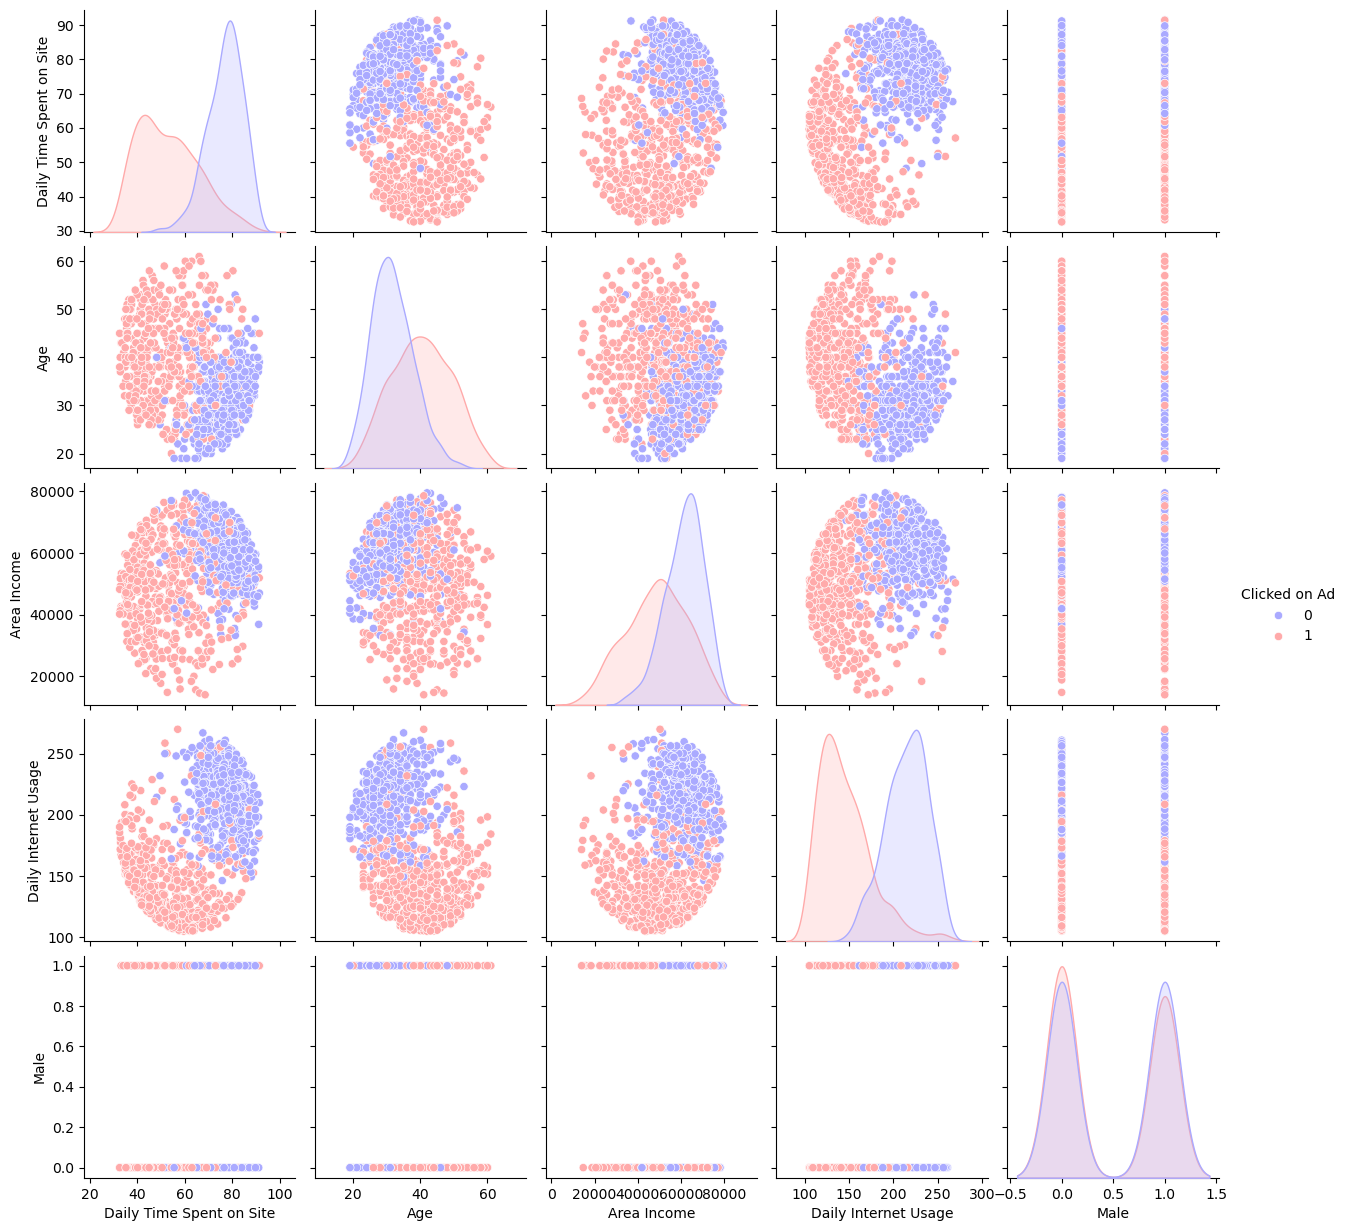

In [25]:
sns.pairplot(data,hue='Clicked on Ad',palette='bwr')
plt.savefig("pairplot.png", dpi=150)
plt.show()

In [27]:
# ============================
# Feature engineering – Timestamp -> Period
# ============================

data['Timestamp'] = pd.to_datetime(data['Timestamp'])

def classify_day_night(timestamp):
    hour = timestamp.hour
    if 6 <= hour < 18:
        return 1
    else:
        return 0

data['Period'] = data['Timestamp'].apply(classify_day_night)
data = data.drop(columns=['Timestamp'], axis=1)

In [29]:
# ============================
# Preprocessing
# ============================

# QuantileTransformer for Age & Area Income
qt = QuantileTransformer(output_distribution='normal')
data[['Age', 'Area Income']] = qt.fit_transform(data[['Age', 'Area Income']])

In [31]:
# PCA for Daily Time Spent on Site & Daily Internet Usage
scaler_pca = StandardScaler()
pca = PCA(n_components=1)

scaled = scaler_pca.fit_transform(
    data[['Daily Time Spent on Site', 'Daily Internet Usage']]
)
pca_col = pca.fit_transform(scaled)

In [33]:
# Replace original cols with PCA
data = data.drop(columns=['Daily Time Spent on Site', 'Daily Internet Usage'])
data['PCAed_Time_Usage'] = pca_col

In [35]:
# Drop unused columns
data = data.drop(columns=['Ad Topic Line', 'City', 'Country'])

# Reorder columns
cols = ['PCAed_Time_Usage', 'Age', 'Area Income', 'Male', 'Period', 'Clicked on Ad']
data = data[cols]

data.head(2)

,PCAed_Time_Usage,Age,Area Income,Male,Period,Clicked on Ad
0,1.402402,0.006273,0.373591,0,0,0
1,0.901517,-0.432104,1.053106,1,0,0


In [37]:
# ============================
# Train / Test split
# ============================

X = data.drop("Clicked on Ad", axis=1).astype('float32')
y = data["Clicked on Ad"].astype('float32')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=40
)

In [39]:
# ============================
# Models: LR, RF, XGB
# ============================

lr = LogisticRegression(max_iter=1000, random_state=40)
lr.fit(X_train, y_train)

rf = RandomForestClassifier(random_state=40)
rf.fit(X_train, y_train)

xgb = XGBClassifier(random_state=40)
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [41]:
# ============================
# TensorFlow Neural Network
# ============================

scaler_tensor = StandardScaler()
X_train_tensor = scaler_tensor.fit_transform(X_train)  # (800, 5)
X_test_tensor = scaler_tensor.transform(X_test)

model = Sequential()
model.add(Input(shape=(5,)))
model.add(Dense(5, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(3, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    loss='binary_crossentropy',
    optimizer=tf.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy']
)

In [43]:
history = model.fit(X_train_tensor, y_train, epochs=50, validation_data=(X_test_tensor, y_test), verbose=1)

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.5075 - loss: 0.6997 - val_accuracy: 0.5850 - val_loss: 0.6821
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5750 - loss: 0.6775 - val_accuracy: 0.6450 - val_loss: 0.6608
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6075 - loss: 0.6592 - val_accuracy: 0.6800 - val_loss: 0.6376
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6200 - loss: 0.6352 - val_accuracy: 0.7450 - val_loss: 0.6119
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6550 - loss: 0.6084 - val_accuracy: 0.7800 - val_loss: 0.5835
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6775 - loss: 0.5886 - val_accuracy: 0.8300 - val_loss: 0.5536
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7225 - loss: 0.5521 - val_accuracy: 0.8700 - val_loss: 0.5195
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7550 - loss: 0.5213 - val_accuracy: 0.8650 - val_

In [45]:
# ============================
# Predictions
# ============================

predictions_lr  = lr.predict(X_test)
predictions_rf  = rf.predict(X_test)
predictions_xgb = xgb.predict(X_test)

In [47]:
nn_probs = model.predict(X_test_tensor).ravel()
predictions_tensor = (nn_probs > 0.5).astype(int)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


In [49]:
# ============================
# Classification reports & confusion matrices (text)
# ============================

print("========== Logistic Regression ============")
print(classification_report(y_test, predictions_lr))
print(confusion_matrix(y_test, predictions_lr))

print("========== Random Forest ============")
print(classification_report(y_test, predictions_rf))
print(confusion_matrix(y_test, predictions_rf))

print("========== XGB ============")
print(classification_report(y_test, predictions_xgb))
print(confusion_matrix(y_test, predictions_xgb))

print("========== TensorFlow ============")
print(classification_report(y_test, predictions_tensor))
print(confusion_matrix(y_test, predictions_tensor))

========== Logistic Regression ============
              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99       112
         1.0       1.00      0.98      0.99        88

    accuracy                           0.99       200
   macro avg       0.99      0.99      0.99       200
weighted avg       0.99      0.99      0.99       200

[[112   0]
 [  2  86]]
========== Random Forest ============
              precision    recall  f1-score   support

         0.0       0.97      0.99      0.98       112
         1.0       0.99      0.97      0.98        88

    accuracy                           0.98       200
   macro avg       0.98      0.98      0.98       200
weighted avg       0.98      0.98      0.98       200

[[111   1]
 [  3  85]]
========== XGB ============
              precision    recall  f1-score   support

         0.0       0.96      1.00      0.98       112
         1.0       1.00      0.94      0.97        88

    accuracy              

<Axes: >

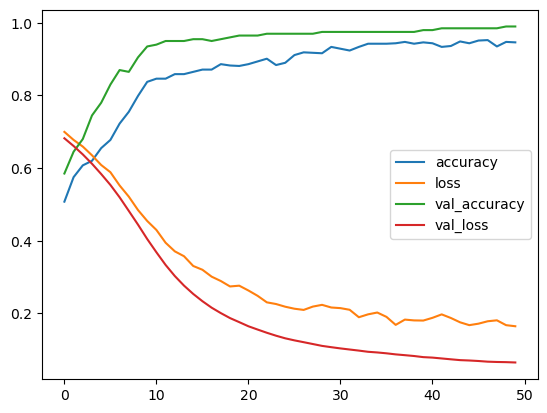

In [51]:
losses = pd.DataFrame(model.history.history)
losses.plot()

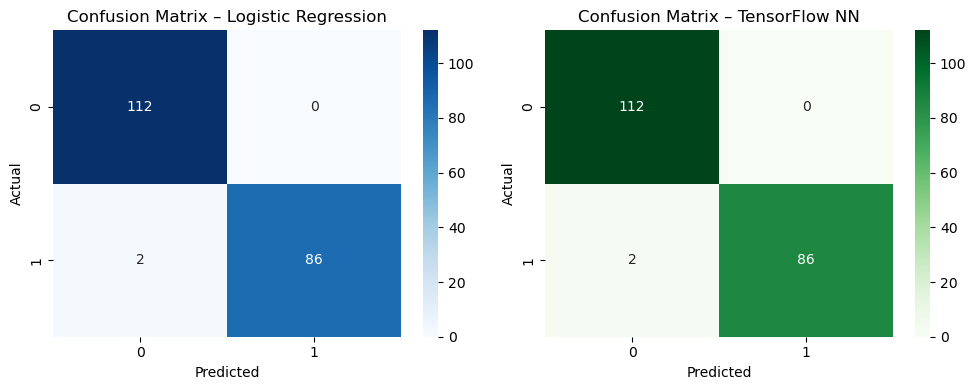

In [65]:
# ============================
# Confusion matrices vizuale (heatmap) – LR & TensorFlow
# ============================

cm_lr = confusion_matrix(y_test, predictions_lr)
cm_nn = confusion_matrix(y_test, predictions_tensor)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Confusion Matrix – Logistic Regression")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm_nn, annot=True, fmt="d", cmap="Greens", ax=axes[1])
axes[1].set_title("Confusion Matrix – TensorFlow NN")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.savefig("fig_confusion_lr_nn.png", dpi=150)
plt.show()

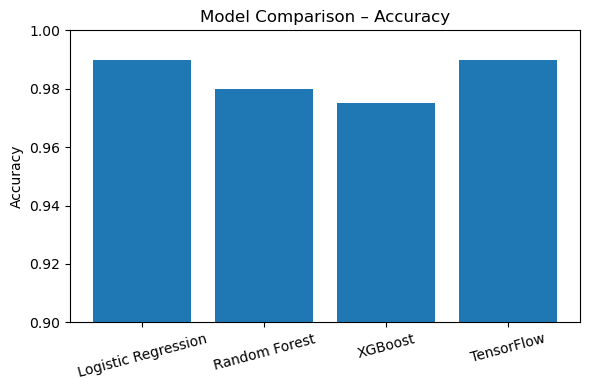

In [67]:
# ============================
# Model comparison – Accuracy bar chart (all 4 models)
# ============================

mods = ['Logistic Regression', 'Random Forest', 'XGBoost', 'TensorFlow']
acc_scores = [
    accuracy_score(y_test, predictions_lr),
    accuracy_score(y_test, predictions_rf),
    accuracy_score(y_test, predictions_xgb),
    accuracy_score(y_test, predictions_tensor)
]

plt.figure(figsize=(6, 4))
plt.bar(mods, acc_scores)
plt.ylim(0.9, 1.0)
plt.ylabel("Accuracy")
plt.title("Model Comparison – Accuracy")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("fig_accuracy_bar.png", dpi=150)
plt.show()

In [69]:
# ============================
# Metrici detaliate pentru LR & TensorFlow
# ============================

# Probabilități LR pentru clasa 1
lr_probs = lr.predict_proba(X_test)[:, 1]

def compute_metrics(y_true, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "ROC_AUC": roc_auc_score(y_true, y_prob),
        "PR_AUC": average_precision_score(y_true, y_prob),
        "Brier": brier_score_loss(y_true, y_prob)
    }

metrics_lr = compute_metrics(y_test, predictions_lr, lr_probs)
metrics_nn = compute_metrics(y_test, predictions_tensor, nn_probs)

metrics_df = pd.DataFrame(
    [metrics_lr, metrics_nn],
    index=["Logistic Regression", "TensorFlow NN"]
)
metrics_df

,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Brier
Logistic Regression,0.99,1.0,0.977273,0.988506,0.999797,0.999747,0.011673
TensorFlow NN,0.99,1.0,0.977273,0.988506,0.999696,0.999625,0.010608


In [71]:
# ============================
# Logistic Regression – Coefficients
# ============================

coeff_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("\nLogistic Regression coefficients:")
print(coeff_df)


Logistic Regression coefficients:
            Feature  Coefficient
1               Age     1.075474
4            Period    -0.136684
3              Male    -0.217117
2       Area Income    -1.495710
0  PCAed_Time_Usage    -3.536087


In [73]:
# ============================
# Error analysis – TensorFlow false predictions
# ============================

results_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': predictions_tensor.flatten()
}, index=y_test.index)

wrong_preds = results_df[results_df['Actual'] != results_df['Predicted']]

print("\nWrong predictions (TensorFlow):")
wrong_preds


Wrong predictions (TensorFlow):


,Actual,Predicted
181,1.0,0
948,1.0,0


In [75]:
print("\nFeature values for wrong predictions:")
print(X_test.loc[wrong_preds.index])


Feature values for wrong predictions:
     PCAed_Time_Usage       Age  Area Income  Male  Period
181          0.683613 -1.031509    -1.018778   0.0     0.0
948         -0.287455 -0.573115     1.926403   1.0     0.0


In [102]:
# Probabilities for specific cases (e.g., 181, 948)
probs = model.predict(X_test_tensor).flatten()
positions = [X_test.index.get_loc(i) for i in [181, 948]]
print(probs[positions])

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
[0.32542717 0.15545708]


In [104]:
# Create prob_df for histogram (NEEDED!)
prob_df = pd.DataFrame({
    'Probability': nn_probs,
    'Actual': y_test.values
})

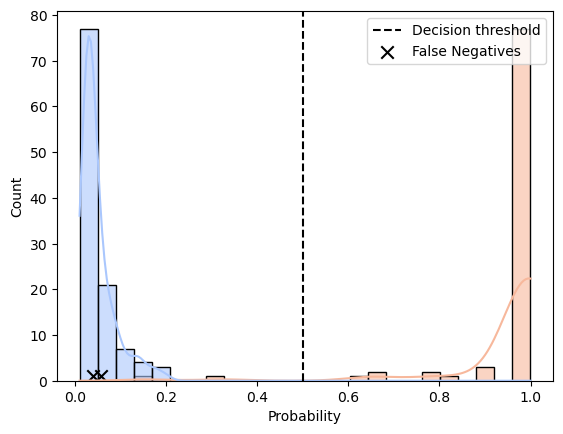

In [106]:
# Probability distribution plot
sns.histplot(
    data=prob_df,
    x='Probability',
    hue='Actual',
    bins=25,
    kde=True,
    palette='coolwarm',
    alpha=0.6
)
plt.axvline(0.5, color='black', linestyle='--', label='Decision threshold')
plt.scatter([probs[0], probs[1]], [1, 1], color='black', marker='x', s=80, label='False Negatives')
plt.legend()
plt.show()

* Let's analyze step by step to understand why the TensorFlow model failed to predict these 2 rows.
* Both cases were click (Actual = 1), but the model predicted 0 - so False Negatives.
* The model believed they won't click, but in reality they did it.
* Due to probabilities for both cases, means that the model was not even close. Actually he was very sure they won't click. So they are false negatives with high confidence.
  The reson why:

Index 181

* PCAed_Time_Usage = 0.68 → quite big (long time on site)
* Age = -1.03 → young
* Area Income = -1.02 → low income
* Male = 0, Period = 0 (night)

* Profile: young, low income, intense internet usage, night.

According to the correlations in the data:

* "Daily Time Spent on Site" is negatively correlated with "Clicked on Ad" (-0.74).
* "Daily Internet Usage" is negatively correlated (-0.79).
* This means that users who spend a lot of time online tend to ignore ads (they don't click).
* Therefore, the model predicted "0" (no click).

However, in reality, this specific case is an exception to the rule.

 Index 948

* PCAed_Time_Usage = -0.29 → Low time spent on the site
* Age = -0.57 → Young user
* Area Income = 1.93 → Very high income
* Male = 1, Period = 0 (Night)

- Profile: A young, wealthy male, who uses the site sparingly, and was browsing at night.

The model likely learned that:

* Users with high income (correlation -0.48) and low usage tend not to click on ads.
* It confidently predicted a 0.11 probability → It was fairly certain he would not click.

But once again, this case is a behavioral outlier: a wealthy user who was either curious or impulsive.

Conclusion: Effectively, these two individuals have behaviors that are opposite to the general trend in the data.

The two errors:

are not due to overfitting or a bug,

but because the model correctly followed the general logic in the data (but the data has real exceptions).

In practical terms, they are completely explainable false negatives.